### ML Lab3
#### Name: Shakir Ali
#### CMS-ID: 023-24-0288
#### Section: H
#### Github: https://github.com/itshakirdev/ML-Labs
#### Kaggle: https://www.kaggle.com/shakiralivii

### Part 1: Problem Definition & Dataset Verification

##### Task 1:
Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.

In [15]:
# Data cleaning

import pandas as pd
import numpy as np

df = pd.read_csv("telco_customer_churn.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [16]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [17]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values in TotalCharges:")
print(df["TotalCharges"].isnull().sum())

Missing values in TotalCharges:
11


In [18]:
df = df.dropna().copy()

print("Cleaned Dataset Shape:", df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Cleaned Dataset Shape: (7032, 21)

Total Missing Values:
0


In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [20]:
print("Final Dataset Shape:")
print(df.shape)

print("\nFinal Data Types:")
print(df.dtypes)

print("\nFinal Missing Values:")
print(df.isnull().sum().sum())

Final Dataset Shape:
(7032, 21)

Final Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Final Missing Values:
0


##### Task 2:
In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

We're predicting whether a telecom customer will churn (leave the company), it matters to the business because catching likely churners early lets them try to retain those customers before they leave.

### Part 2: Feature & Target Preparation

##### Task 3:
Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present.

In [21]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


##### Task 4:
Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).

In [22]:
print(X.dtypes.value_counts())

X = pd.get_dummies(X, drop_first=True)

print(X.dtypes.value_counts())

str        15
int64       2
float64     2
Name: count, dtype: int64
bool       26
int64       2
float64     2
Name: count, dtype: int64


In [23]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()

X = df.drop(columns=["Churn", "customerID"])
X = pd.get_dummies(X, drop_first=True)

print("Number of features:", X.shape[1])

Number of features: 30


I used one-hot encoding to convert categorical features into numerical values. One-hot encoding is suitable because it represents each category as a separate binary feature without creating an artificial numerical ordering between categories. I used `drop_first=True` to remove one redundant category from each categorical group.


##### Task 5:
Confirm X contains only numeric columns and has no missing values before moving on.

In [24]:
print("Missing values:", X.isnull().sum().sum())
print("Number of features:", X.shape[1])

Missing values: 0
Number of features: 30


### Part 3: Train/Test Split

##### Task 6:
Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2?

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

##### Task 7:
Report the shape of X_train, X_test, y_train, and y_test.

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


### Part 4: Baseline Decision Tree

##### Task 8:
Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets.

In [28]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

y_train_pred = baseline.predict(X_train)
y_test_pred = baseline.predict(X_test)

##### Task 9:
What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [29]:
print("Tree depth:", baseline.get_depth())

Tree depth: 23


### Part 5: Model Evaluation

##### Task 10:
Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7185501066098081
Precision: 0.4701086956521739
Recall   : 0.4625668449197861
F1-score : 0.46630727762803237


##### Task 11:
Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?

[[838 195]
 [201 173]]


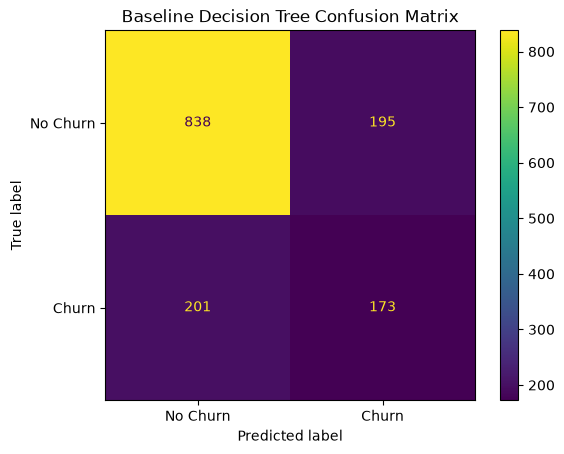

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Baseline Decision Tree Confusion Matrix")
plt.show()

##### Task 12:
Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

Since Churn is imbalanced, recall and F1-score matter more than accuracy here, cuz recall tells us how many actual churners we caught, which is what the business actually cares about.

### Part 6: Overfitting Investigation

##### Task 13:
Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?

In [32]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Train accuracy: 0.9987555555555555
Test accuracy: 0.7185501066098081


##### Task 14:
Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.

In [33]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

   max_depth  train_accuracy  test_accuracy   test_f1
0        2.0        0.791289       0.784648  0.495840
1        3.0        0.791289       0.784648  0.495840
2        4.0        0.796089       0.783227  0.550810
3        5.0        0.801956       0.778252  0.588391
4        6.0        0.812978       0.785359  0.567335
5        8.0        0.836622       0.782516  0.556522
6       10.0        0.874311       0.752665  0.483680
7        NaN        0.998756       0.718550  0.466307


##### Task 15:
Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

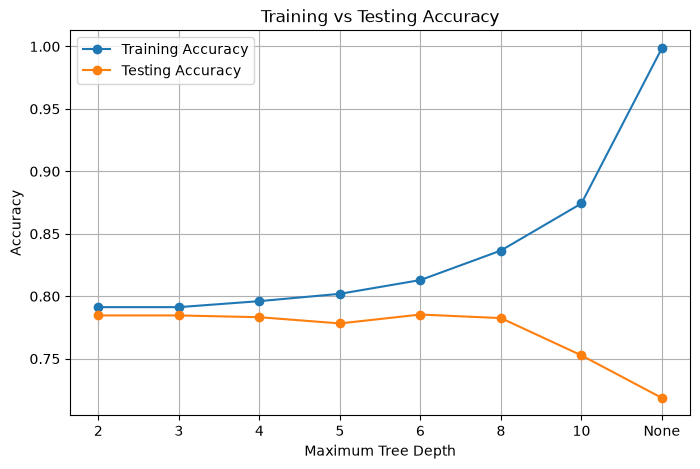

In [34]:
plt.figure(figsize=(8, 5))

depth_labels = results_df["max_depth"].apply(lambda d: "None" if pd.isnull(d) else str(int(d)))

plt.plot(depth_labels, results_df["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(depth_labels, results_df["test_accuracy"], marker="o", label="Testing Accuracy")

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Part 7: Model Selection, Feature Importance & Interpretation

##### Task 16:
Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.

Picked max_depth=5 as best model, not the one with highest training accuracy, cuz it had the best test F1-score (58.8%) out of all depths, meaning it balances catching churners without overfitting to noise.

##### Task 17:
Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline.

Accuracy : 0.7782515991471215
Precision: 0.5807291666666666
Recall   : 0.5962566844919787
F1-score : 0.5883905013192612
[[872 161]
 [151 223]]


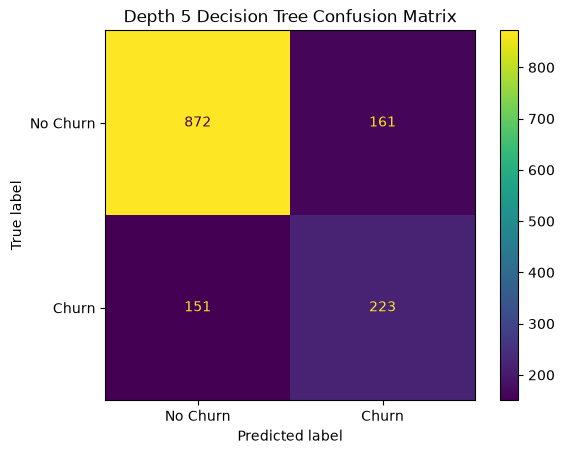

In [35]:
best_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1-score :", f1_score(y_test, best_pred))

cm_best = confusion_matrix(y_test, best_pred)
print(cm_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["No Churn", "Churn"])
disp.plot()
plt.title("Depth 5 Decision Tree Confusion Matrix")
plt.show()

##### Task 18:
Retrain a Decision Tree with "entropy" as the splitting criterion rather than the default ("gini") and report its full evaluation metrics (as in Part 5) for comparison against the baseline.

In [36]:
entropy_model = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
entropy_model.fit(X_train, y_train)
entropy_pred = entropy_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, entropy_pred))
print("Precision:", precision_score(y_test, entropy_pred))
print("Recall   :", recall_score(y_test, entropy_pred))
print("F1-score :", f1_score(y_test, entropy_pred))

Accuracy : 0.775408670931059
Precision: 0.597972972972973
Recall   : 0.4732620320855615
F1-score : 0.5283582089552239


##### Task 19:
Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?

tenure                                 0.441283
InternetService_Fiber optic            0.338826
TotalCharges                           0.033886
PaymentMethod_Electronic check         0.026809
OnlineSecurity_No internet service     0.026778
MonthlyCharges                         0.025198
Contract_Two year                      0.019312
StreamingMovies_No internet service    0.015402
OnlineSecurity_Yes                     0.015138
TechSupport_Yes                        0.012159
dtype: float64


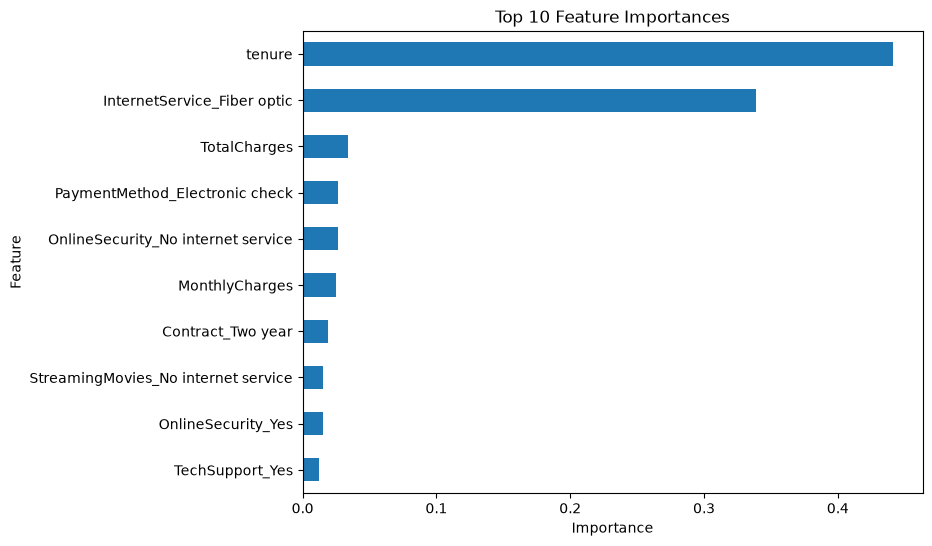

In [37]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

##### Task 20:
In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

These top features match what I found in Lab 2, tenure was already linked to churn there and fiber optic/electronic check customers also showed higher churn rates in the bivariate analysis, so the model agrees with the earlier EDA patterns.

### Part 8: Conclusion & Next Steps

##### Task 21:
Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?

Landed on the depth 5 Decision Tree, it gets 77.8% accuracy, 58% precision, 59.6% recall and 58.8% f1, its way better than the overfit baseline but still misses some churners so its not perfect, main limitation is it still misses around 40% of actual churners.

##### Task 22:
What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

If had more time would try handling class imbalance with class weighting, do more feature engineering, and try other algorithms like random forest to see if recall improves.

##### Task 23:
Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — write your own entropy and information gain functions. Print the gain values for each attribute at every split.

In [38]:
import math
from collections import Counter

data = [
    ["Sunny","Hot","High","Weak","No"],
    ["Sunny","Hot","High","Strong","No"],
    ["Overcast","Hot","High","Weak","Yes"],
    ["Rainy","Mild","High","Weak","Yes"],
    ["Rainy","Cool","Normal","Weak","Yes"],
    ["Rainy","Cool","Normal","Strong","No"],
    ["Overcast","Cool","Normal","Strong","Yes"],
    ["Sunny","Mild","High","Weak","No"],
    ["Sunny","Cool","Normal","Weak","Yes"],
    ["Rainy","Mild","Normal","Weak","Yes"],
    ["Sunny","Mild","Normal","Strong","Yes"],
    ["Overcast","Mild","High","Strong","Yes"],
    ["Overcast","Hot","Normal","Weak","Yes"],
    ["Rainy","Mild","High","Strong","No"],
]

columns = ["Outlook","Temperature","Humidity","Windy","PlayTennis"]

def entropy(rows):
    total = len(rows)
    labels = [row[-1] for row in rows]
    counts = Counter(labels)
    ent = 0
    for label in counts:
        p = counts[label] / total
        ent -= p * math.log2(p)
    return ent

def split_by_attribute(rows, attr_index):
    subsets = {}
    for row in rows:
        key = row[attr_index]
        subsets.setdefault(key, []).append(row)
    return subsets

def information_gain(rows, attr_index):
    total_entropy = entropy(rows)
    total = len(rows)
    subsets = split_by_attribute(rows, attr_index)
    weighted_entropy = 0
    for key in subsets:
        weighted_entropy += (len(subsets[key]) / total) * entropy(subsets[key])
    return total_entropy - weighted_entropy

def best_attribute(rows, attr_indices, attr_names):
    print("Entropy of current node:", round(entropy(rows), 4))
    gains = {}
    for idx in attr_indices:
        gain = information_gain(rows, idx)
        gains[idx] = gain
        print(f"Gain({attr_names[idx]}) = {round(gain, 4)}")
    best_idx = max(gains, key=gains.get)
    print(f"--> Best attribute: {attr_names[best_idx]} (Gain = {round(gains[best_idx], 4)})\n")
    return best_idx

def majority_label(rows):
    labels = [row[-1] for row in rows]
    return Counter(labels).most_common(1)[0][0]

def build_tree(rows, attr_indices, attr_names, depth=0):
    labels = [row[-1] for row in rows]
    if labels.count(labels[0]) == len(labels):
        return labels[0]

    if not attr_indices:
        return majority_label(rows)

    print("  " * depth + f"Splitting node with {len(rows)} rows on attributes {[attr_names[i] for i in attr_indices]}")
    best_idx = best_attribute(rows, attr_indices, attr_names)
    tree = {attr_names[best_idx]: {}}

    subsets = split_by_attribute(rows, best_idx)
    remaining_attrs = [i for i in attr_indices if i != best_idx]

    for value, subset in subsets.items():
        print("  " * depth + f"-> {attr_names[best_idx]} = {value} ({len(subset)} rows)")
        subtree = build_tree(subset, remaining_attrs, attr_names, depth + 1)
        tree[attr_names[best_idx]][value] = subtree

    return tree

attr_indices = [0, 1, 2, 3]
tree = build_tree(data, attr_indices, columns)

Splitting node with 14 rows on attributes ['Outlook', 'Temperature', 'Humidity', 'Windy']
Entropy of current node: 0.9403
Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Windy) = 0.0481
--> Best attribute: Outlook (Gain = 0.2467)

-> Outlook = Sunny (5 rows)
  Splitting node with 5 rows on attributes ['Temperature', 'Humidity', 'Windy']
Entropy of current node: 0.971
Gain(Temperature) = 0.571
Gain(Humidity) = 0.971
Gain(Windy) = 0.02
--> Best attribute: Humidity (Gain = 0.971)

  -> Humidity = High (3 rows)
  -> Humidity = Normal (2 rows)
-> Outlook = Overcast (4 rows)
-> Outlook = Rainy (5 rows)
  Splitting node with 5 rows on attributes ['Temperature', 'Humidity', 'Windy']
Entropy of current node: 0.971
Gain(Temperature) = 0.02
Gain(Humidity) = 0.02
Gain(Windy) = 0.971
--> Best attribute: Windy (Gain = 0.971)

  -> Windy = Weak (3 rows)
  -> Windy = Strong (2 rows)


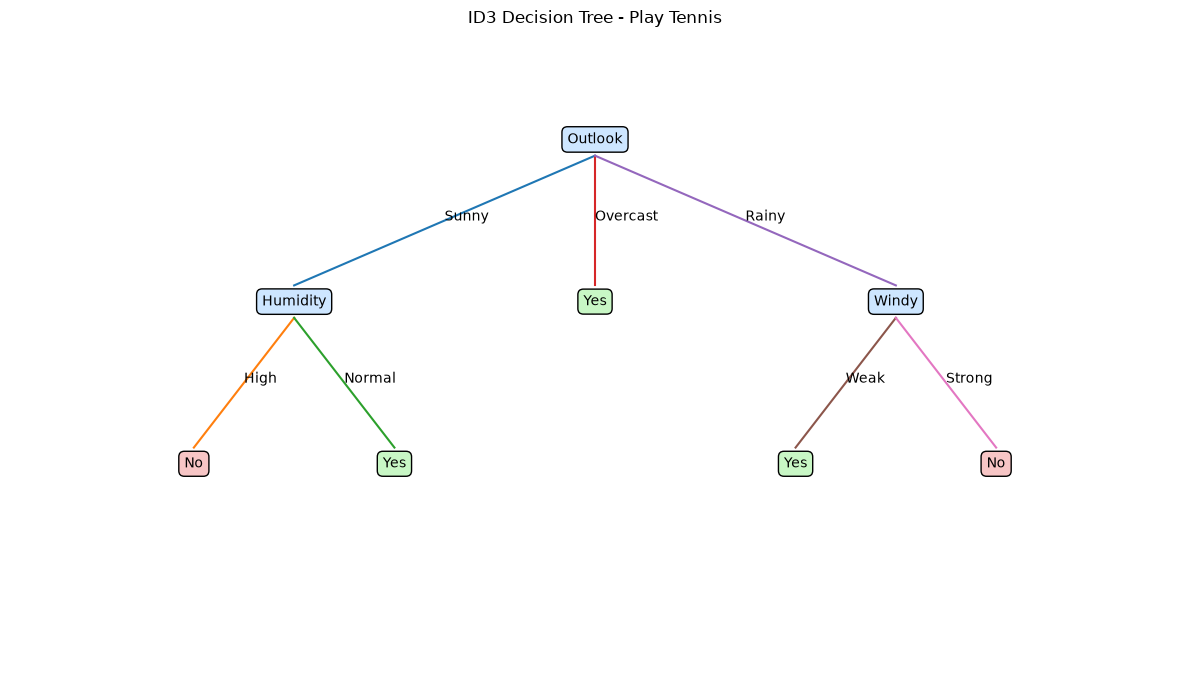

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

def get_width(node):
    if not isinstance(node, dict):
        return 1
    attr = list(node.keys())[0]
    branches = node[attr]
    return sum(get_width(v) for v in branches.values())

def plot_node(ax, text, x, y, is_leaf=False):
    color = "#cde6ff" if not is_leaf else ("#c8f7c5" if text == "Yes" else "#f7c5c5")
    ax.text(x, y, text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="black"))

def draw(node, x, y, x_range, ax):
    if not isinstance(node, dict):
        plot_node(ax, str(node), x, y, is_leaf=True)
        return

    attr = list(node.keys())[0]
    branches = node[attr]
    plot_node(ax, attr, x, y)

    total_width = sum(get_width(v) for v in branches.values())
    left = x - x_range / 2
    child_y = y - 1.5

    for value, child in branches.items():
        w = get_width(child)
        child_x = left + (w / total_width) * x_range * 0.5 + left
        child_x = left + (w / 2 / total_width) * x_range
        ax.plot([x, child_x], [y - 0.15, child_y + 0.15])
        mid_x = (x + child_x) / 2
        mid_y = (y + child_y) / 2
        ax.text(mid_x, mid_y, str(value))
        draw(child, child_x, child_y, (w / total_width) * x_range, ax)
        left += (w / total_width) * x_range

draw(tree, x=0, y=0, x_range=12, ax=ax)
ax.set_xlim(-7, 7)
ax.set_ylim(-5, 1)
plt.title("ID3 Decision Tree - Play Tennis")
plt.tight_layout()
plt.show()